In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on:", device)


Running on: cuda


In [2]:
NOISE_DIM = 100
TEXT_EMBED_DIM = 128
VOCAB_SIZE = 1024
SEQ_LEN = 5

IMG_SIZE = 64
BATCH_SIZE = 64
EPOCHS = 20          # Keep low for Kaggle
LR = 1e-4
LAMBDA_GP = 10
CRITIC_ITERS = 5


In [3]:
class TextEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 64)
        self.lstm = nn.LSTM(64, embed_dim, batch_first=True)

    def forward(self, text_seq):
        x = self.embedding(text_seq)
        _, (h, _) = self.lstm(x)
        return h.squeeze(0)


In [4]:
def get_text_batch(labels):
    return labels.view(-1,1).repeat(1, SEQ_LEN).to(device)


In [5]:
class SelfAttention(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.query = nn.Conv2d(in_dim, in_dim//8, 1)
        self.key   = nn.Conv2d(in_dim, in_dim//8, 1)
        self.value = nn.Conv2d(in_dim, in_dim, 1)
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        B, C, H, W = x.size()
        q = self.query(x).view(B, -1, H*W).permute(0,2,1)
        k = self.key(x).view(B, -1, H*W)
        attn = torch.softmax(torch.bmm(q, k), dim=-1)
        v = self.value(x).view(B, -1, H*W)

        out = torch.bmm(v, attn.permute(0,2,1))
        out = out.view(B, C, H, W)
        return self.gamma * out + x


In [6]:
class CrossAttention(nn.Module):
    def __init__(self, img_dim, text_dim):
        super().__init__()
        self.query = nn.Conv2d(img_dim, img_dim//8, 1)
        self.key   = nn.Linear(text_dim, img_dim//8)
        self.value = nn.Linear(text_dim, img_dim)

    def forward(self, img_feat, text_embed):
        B, C, H, W = img_feat.size()
        q = self.query(img_feat).view(B, -1, H*W).permute(0,2,1)
        k = self.key(text_embed).unsqueeze(1)
        v = self.value(text_embed).unsqueeze(1)

        attn = torch.softmax(torch.bmm(q, k.transpose(1,2)), dim=1)
        out = attn * v
        out = out.sum(dim=1).view(B, C, 1, 1)
        return img_feat + out


In [7]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(NOISE_DIM + TEXT_EMBED_DIM, 512*4*4)

        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )

        self.attn = SelfAttention(256)
        self.cross_attn = CrossAttention(256, TEXT_EMBED_DIM)

        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, z, text_embed):
        x = torch.cat([z, text_embed], dim=1)
        x = self.fc(x).view(-1, 512, 4, 4)
        x = self.up1(x)
        x = self.attn(x)
        x = self.cross_attn(x, text_embed)
        return self.up2(x)


In [8]:
class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2),
            SelfAttention(128),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.InstanceNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 512, 4, 2, 1),
            nn.InstanceNorm2d(512),
            nn.LeakyReLU(0.2)
        )

        self.fc = nn.Linear(512*4*4 + TEXT_EMBED_DIM, 1)

    def forward(self, img, text_embed):
        x = self.net(img)
        x = x.view(x.size(0), -1)
        x = torch.cat([x, text_embed], dim=1)
        return self.fc(x)


In [9]:
def gradient_penalty(critic, real, fake, text_embed):
    alpha = torch.rand(real.size(0), 1, 1, 1).to(device)
    interp = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    out = critic(interp, text_embed)

    grad = torch.autograd.grad(
        outputs=out,
        inputs=interp,
        grad_outputs=torch.ones_like(out),
        create_graph=True
    )[0]

    grad = grad.view(grad.size(0), -1)
    return ((grad.norm(2, dim=1) - 1) ** 2).mean()


In [10]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

dataset = torchvision.datasets.Flowers102(
    root="/kaggle/working",
    split="train",
    download=True,
    transform=transform
)

loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)


100%|██████████| 345M/345M [00:08<00:00, 40.0MB/s] 
100%|██████████| 502/502 [00:00<00:00, 2.28MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 34.2MB/s]


In [13]:
for epoch in range(EPOCHS):
    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        text_seq = get_text_batch(labels)

        # =======================
        # 1️⃣ CRITIC UPDATE
        # =======================
        with torch.no_grad():
            text_embed_C = text_encoder(text_seq)

        for _ in range(CRITIC_ITERS):
            z = torch.randn(imgs.size(0), NOISE_DIM).to(device)
            fake_imgs = G(z, text_embed_C)

            gp = gradient_penalty(C, imgs, fake_imgs, text_embed_C)

            c_real = C(imgs, text_embed_C)
            c_fake = C(fake_imgs.detach(), text_embed_C)

            loss_C = -(c_real.mean() - c_fake.mean()) + LAMBDA_GP * gp

            opt_C.zero_grad()
            loss_C.backward()
            opt_C.step()

        # =======================
        # 2️⃣ GENERATOR UPDATE
        # =======================
        text_embed_G = text_encoder(text_seq)

        z = torch.randn(imgs.size(0), NOISE_DIM).to(device)
        fake_imgs = G(z, text_embed_G)

        loss_G = -C(fake_imgs, text_embed_G).mean()

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Critic Loss: {loss_C.item():.4f} | "
        f"Gen Loss: {loss_G.item():.4f}"
    )


Epoch [1/20] | Critic Loss: -52.6044 | Gen Loss: 35.8821
Epoch [2/20] | Critic Loss: -43.7462 | Gen Loss: 18.2149
Epoch [3/20] | Critic Loss: -37.9525 | Gen Loss: 40.6551
Epoch [4/20] | Critic Loss: -36.1812 | Gen Loss: 41.6212
Epoch [5/20] | Critic Loss: -29.7153 | Gen Loss: 39.2188
Epoch [6/20] | Critic Loss: -29.8318 | Gen Loss: 37.6213
Epoch [7/20] | Critic Loss: -29.0506 | Gen Loss: 37.2160
Epoch [8/20] | Critic Loss: -26.9283 | Gen Loss: 36.2002
Epoch [9/20] | Critic Loss: -28.0337 | Gen Loss: 44.6194
Epoch [10/20] | Critic Loss: -30.5017 | Gen Loss: 43.7904
Epoch [11/20] | Critic Loss: -30.5990 | Gen Loss: 53.6234
Epoch [12/20] | Critic Loss: -26.3465 | Gen Loss: 50.4833
Epoch [13/20] | Critic Loss: -25.4184 | Gen Loss: 53.9355
Epoch [14/20] | Critic Loss: -28.1547 | Gen Loss: 52.0985
Epoch [15/20] | Critic Loss: -29.9047 | Gen Loss: 59.3542
Epoch [16/20] | Critic Loss: -17.5225 | Gen Loss: 46.7915
Epoch [17/20] | Critic Loss: -18.0808 | Gen Loss: 45.8449
Epoch [18/20] | Critic 

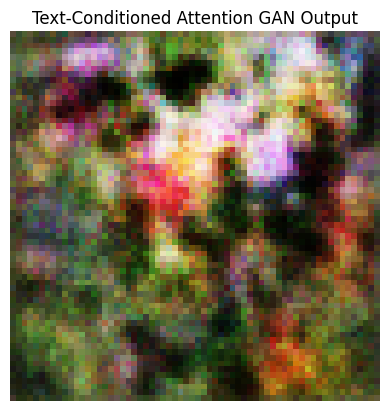

In [14]:
with torch.no_grad():
    label = torch.tensor([5]).to(device)
    text = get_text_batch(label)
    embed = text_encoder(text)
    z = torch.randn(1, NOISE_DIM).to(device)
    img = G(z, embed).cpu()

plt.imshow((img[0].permute(1,2,0)+1)/2)
plt.axis("off")
plt.title("Text-Conditioned Attention GAN Output")
plt.show()
